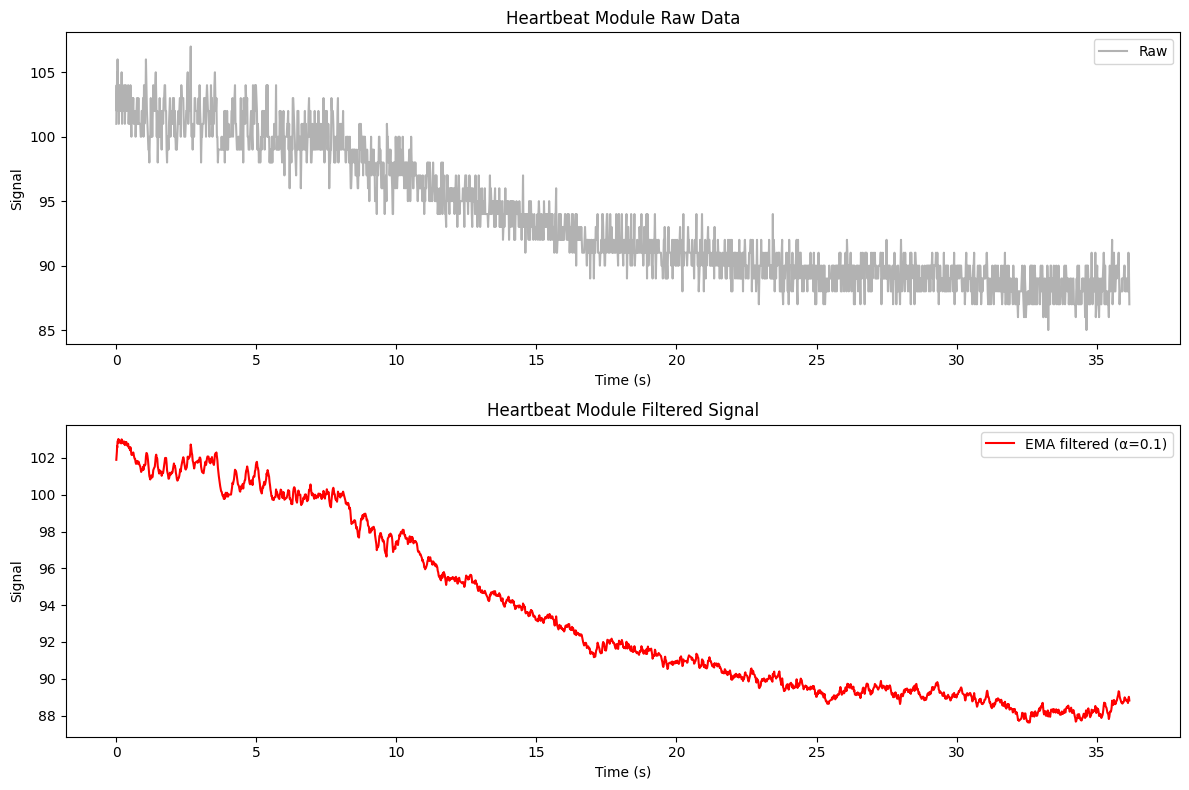

Average interval: 1.23 seconds
Estimated BPM: 48.7

── curve_fit results ──
Amplitude: 0.197
Frequency: 0.8004 Hz
BPM from curve_fit: 48.0


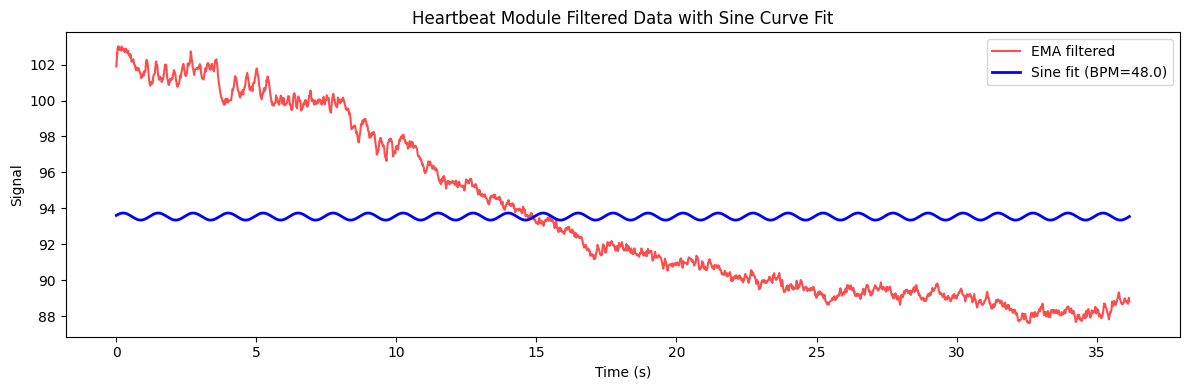

Frequency:  0.8004 ± 0.0113 Hz


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

path = "/content/advlabfinalproject.csv"
data = np.genfromtxt(path, delimiter=',', names='time, raw, filtered')

time = data['time']*0.001
raw = data['raw']
filtered = data['filtered']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
ax1.plot(time, raw, alpha=0.6, color='gray', label='Raw')
ax1.set_title('Heartbeat Module Raw Data')
ax1.set_ylabel('Signal')
ax1.set_xlabel('Time (s)')
ax1.legend()

ax2.plot(time, filtered, color='red', label='EMA filtered (α=0.1)')
ax2.set_title('Heartbeat Module Filtered Signal')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Signal')
ax2.legend()

plt.tight_layout()
plt.show()

peaks, _ = find_peaks(filtered, distance=50, prominence=0.2)
peak_times = time[peaks]
if len(peak_times) > 1:
    intervals = np.diff(peak_times)
    avg_interval = np.mean(intervals)
    bpm = 60 / avg_interval
    print(f"Average interval: {avg_interval:.2f} seconds")
    print(f"Estimated BPM: {bpm:.1f}")

def sine_model(t, A, f, phi, offset): #adapted from https://stackoverflow.com/questions/75222565/sine-curve-fitting-in-python
    return A * np.sin(2 * np.pi * f * t + phi) + offset

A_guess = (np.max(filtered) - np.min(filtered)) / 2
f_guess = 1 / avg_interval
offset_guess = np.mean(filtered)

try:
    popt, pcov = curve_fit(
        sine_model, time, filtered,
        p0=[A_guess, f_guess, 0, offset_guess],
        maxfev=10000
    )
    A_fit, f_fit, phi_fit, offset_fit = popt
    bpm_fit = f_fit * 60

    print(f"\n── curve_fit results ──")
    print(f"Amplitude: {A_fit:.3f}")
    print(f"Frequency: {f_fit:.4f} Hz")
    print(f"BPM from curve_fit: {bpm_fit:.1f}")

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(time, filtered, color='red', alpha=0.7, label='EMA filtered')
    ax.plot(time, sine_model(time, *popt), color='blue',
            linewidth=2, label=f'Sine fit (BPM={bpm_fit:.1f})')
    ax.set_title('Heartbeat Module Filtered Data with Sine Curve Fit')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Signal')
    ax.legend()
    plt.tight_layout()
    plt.show()

except RuntimeError:
    print("curve_fit did not converge — try adjusting p0 guesses")

perr = np.sqrt(np.diag(pcov))
print(f"Frequency:  {f_fit:.4f} ± {perr[1]:.4f} Hz")
